### [생선 무게 예측 회귀 모델 구현]
- 데이터 관련
    * 로딩 및 기본 확인 : EDA
    * 전처리 진행
    * 데이터 가공 (통계치 X) : 불필요 컬럼 제거

- 학습 관련
    * 피쳐, 타겟 분리
    * 데이터셋 분리 : 학습|검증|테스트
    * 학습용 데이터 가공 -> 데이터 누수 예방
    * 학습/검증/테스트 함수

- 학습 진행
    * 학습 관련 설정값
    * 학습 관련 인스턴스들
    * 학습 진행 + 진행 과정에 대한 로그 : 학습과 검증의 loss, score 등등

- 학습 평가
    * 학습 과정 로그기반 시각화
    * 과대/과소/최적 평가

In [1]:
import pandas as pd, torch, sys, matplotlib.pyplot as plt, koreanize_matplotlib
sys.path.append('../DAY05')
from dnn_fish_class import *
from reg_func import *

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
from torch.optim import Adam
from torch.nn import MSELoss

from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv('../../[8] 머신러닝/Data/Numbers/fish.csv')
df = df.drop(columns=['Species'])

In [3]:
# 데이터 컬럼별 값의 범위 확인
df.describe()

# 피쳐별 값의 범위 차이 존재 -> 스케일링 필요
# 타겟 컬럼 Weight 이상치(0) 존재

,Weight,Length,Diagonal,Height,Width
count,159.000000,159.000000,159.000000,159.000000,159.000000
mean,398.326415,28.415723,31.227044,8.970994,4.417486
std,357.978317,10.716328,11.610246,4.286208,1.685804
min,0.000000,8.400000,8.800000,1.728400,1.047600
25%,120.000000,21.000000,23.150000,5.944800,3.385650
50%,273.000000,27.300000,29.400000,7.786000,4.248500
75%,650.000000,35.500000,39.650000,12.365900,5.584500
max,1650.000000,63.400000,68.000000,18.957000,8.142000


In [4]:
display((df['Weight'] == 0).sum())

zero_idx = (df[df['Weight'] == 0]).index.to_list()
print(zero_idx)

np.int64(1)

[40]


In [5]:
# 삭제
df = df.drop(index=zero_idx)
df = df.reset_index(drop=True)
display((df['Weight'] == 0).sum())
df.describe()

np.int64(0)

,Weight,Length,Diagonal,Height,Width
count,158.000000,158.000000,158.000000,158.000000,158.000000
mean,400.847468,28.465823,31.280380,8.986790,4.424232
std,357.697796,10.731707,11.627605,4.295191,1.689010
min,5.900000,8.400000,8.800000,1.728400,1.047600
25%,121.250000,21.000000,23.200000,5.940600,3.398650
50%,281.500000,27.400000,29.700000,7.789000,4.277050
75%,650.000000,35.750000,39.675000,12.371850,5.586750
max,1650.000000,63.400000,68.000000,18.957000,8.142000


>> [2] 학습 데이터 준비

In [6]:
# 피쳐와 타겟 분리
feature = df[df.columns[1:]]
target = df[df.columns[0]]

In [7]:
# 타겟 컬럼 스케일링 여부 결정
# target.describe()

# [결정] ----------------------
# - 값들의 범위가 넓게 퍼짐 즉, 값의 차이 큼!
# - 오른쪽에서 즉, 큰 무게에 해당하는 데이터가 더 많음
# - 타겟도 스케링ㄹ링 필요함
# - 값의 차이 크기 때문에 학습용 기준 스케일링 진행
# - 검증용/테스트용에 적용

In [8]:
# 데이터셋 분리 : 학습|검증|테스트
# 학습용 : 테스트용 = 8:2
x_train, x_test, y_train, y_test = train_test_split(feature, target,
                                                    test_size=0.2,
                                                    random_state=42)
# 학습용 : 검증용 = 8:2
x_train, x_valid, y_train, y_valid = train_test_split(x_train, y_train,
                                                    test_size=0.2,
                                                    random_state=42)
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)
print(x_valid.shape, y_valid.shape)

(100, 4) (100,)
(32, 4) (32,)
(26, 4) (26,)


In [9]:
# 학습용 기준 피쳐별 스케일링
# 딥러닝 삭습 시 권장 사항
# 평균0, 표준편차1이 되는 데이터를 좋아함
from sklearn.preprocessing import StandardScaler
target_scaler = StandardScaler()
scaled_y_train = target_scaler.fit_transform(y_train.to_frame())
scaled_y_valid = target_scaler.transform(y_valid.to_frame())
scaled_y_test  = target_scaler.transform(y_test.to_frame())

In [10]:
# 학습용 기준 피쳐 스케일링, 검증용/테스트용은 transform만
feature_scaler = StandardScaler()
scaled_x_train = feature_scaler.fit_transform(x_train)
scaled_x_valid = feature_scaler.transform(x_valid)
scaled_x_test  = feature_scaler.transform(x_test)

In [11]:
# 학습 진행 관련 설정
epochs = 300
bs = 16

# W,B 업데이트/ 값 보정 간격
LR = 0.001

# 학습위치
DIVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

In [12]:
model = Fish_W_Cls().to(DIVICE)

adam = Adam(model.parameters(), lr=LR)
lossFN = MSELoss()

trainDL = DataLoader(Fish_W_Ds(scaled_x_train, scaled_y_train), batch_size=bs, shuffle=True)
validDL = DataLoader(Fish_W_Ds(scaled_x_valid, scaled_y_valid), batch_size=bs)
testDL  = DataLoader(Fish_W_Ds(scaled_x_test, scaled_y_test), batch_size=bs)

In [13]:
lossEpoch = {'Train':[], 'Valid':[]}
r2Epoch   = {'Train':[], 'Valid':[]}

for epo in range(epochs):
    t_loss, t_mse, t_rmse, t_r2 = training_regression(model, trainDL, lossFN, adam, DIVICE)
    v_loss, v_mse, v_rmse, v_r2 = evaluating_regression(model, validDL, lossFN, DIVICE)

    lossEpoch['Train'].append(t_loss); lossEpoch['Valid'].append(v_loss)
    r2Epoch['Train'].append(t_r2);     r2Epoch['Valid'].append(v_r2)

    if not epo % 10:
        print(f"[EPOCH-{epo:04}] TRAIN LOSS:{t_loss:.5f} R2:{t_r2:.5f}", end='   ')
        print(f"VALID LOSS:{v_loss:.5f} R2:{v_r2:.5f}")

[EPOCH-0000] TRAIN LOSS:14.76697 R2:-0.03369   VALID LOSS:14.87932 R2:0.18631
[EPOCH-0010] TRAIN LOSS:11.79431 R2:0.17440   VALID LOSS:11.93486 R2:0.34733
[EPOCH-0020] TRAIN LOSS:10.05070 R2:0.29645   VALID LOSS:10.17328 R2:0.44366
[EPOCH-0030] TRAIN LOSS:8.72626 R2:0.38916   VALID LOSS:8.86271 R2:0.51533
[EPOCH-0040] TRAIN LOSS:7.62396 R2:0.46632   VALID LOSS:7.82049 R2:0.57233
[EPOCH-0050] TRAIN LOSS:6.63109 R2:0.53582   VALID LOSS:6.82396 R2:0.62682
[EPOCH-0060] TRAIN LOSS:5.74114 R2:0.59812   VALID LOSS:5.95255 R2:0.67448
[EPOCH-0070] TRAIN LOSS:4.94291 R2:0.65400   VALID LOSS:5.15210 R2:0.71825
[EPOCH-0080] TRAIN LOSS:4.26092 R2:0.70174   VALID LOSS:4.48585 R2:0.75469
[EPOCH-0090] TRAIN LOSS:3.66259 R2:0.74362   VALID LOSS:3.89577 R2:0.78696
[EPOCH-0100] TRAIN LOSS:3.16465 R2:0.77847   VALID LOSS:3.41021 R2:0.81351
[EPOCH-0110] TRAIN LOSS:2.73950 R2:0.80824   VALID LOSS:2.95492 R2:0.83841
[EPOCH-0120] TRAIN LOSS:2.38299 R2:0.83319   VALID LOSS:2.61370 R2:0.85707
[EPOCH-0130] TRAIN

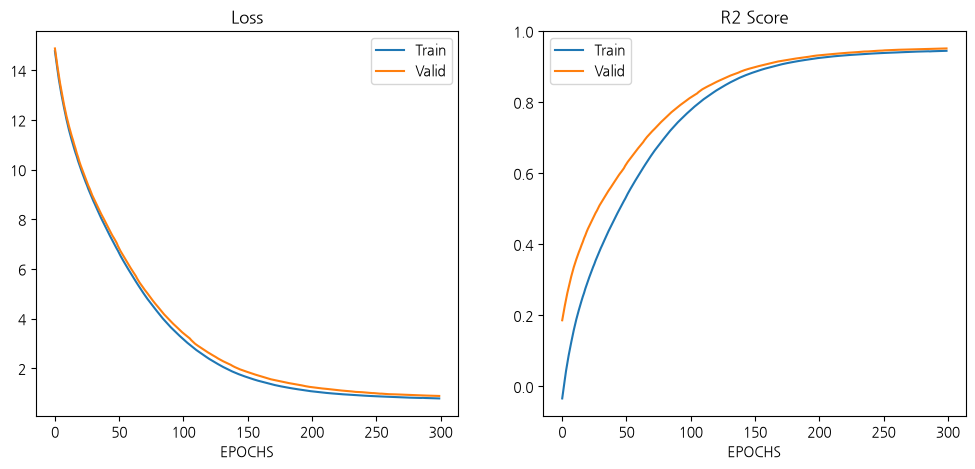

[TEST] LOSS:1.00663  MSE:0.06291  RMSE:0.25083  R2:0.94628


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

axes[0].plot(lossEpoch['Train'], label='Train')
axes[0].plot(lossEpoch['Valid'], label='Valid')
axes[0].set_title('Loss'); axes[0].set_xlabel('EPOCHS'); axes[0].legend()

axes[1].plot(r2Epoch['Train'], label='Train')
axes[1].plot(r2Epoch['Valid'], label='Valid')
axes[1].set_title('R2 Score'); axes[1].set_xlabel('EPOCHS'); axes[1].legend()

plt.show()

test_loss, test_mse, test_rmse, test_r2 = evaluating_regression(model, testDL, lossFN, DIVICE)
print(f"[TEST] LOSS:{test_loss:.5f}  MSE:{test_mse:.5f}  RMSE:{test_rmse:.5f}  R2:{test_r2:.5f}")